# Notebook 01 — Exploratory Data Analysis (EDA)
**SpiritComp — Telecom Complaint Analytics & Network Intelligence Platform**
Huawei Technologies / PFE Master Engineering

**Scope (current phase):** Sheet1 (complaints) only.
DATA / VOICE KPI sheets are not yet available from Huawei.
Synthetic KPI data is generated in the second half of this notebook.

**Outputs:**
- `reports/figures/eda_*.png`   — individual EDA charts
- `reports/figures/D1_EDA_Summary_Report.png` — deliverable D1 figure
- `data/raw/synthetic_kpi.parquet`  — synthetic KPI for downstream notebooks

## Cell 0 — Environment & version check

In [43]:
# FIX N1: replaced hardcoded Windows path with portable project-root detection.
# This works on every machine regardless of OS or username.
import sys
from pathlib import Path

# Walk up until we find config/config.yaml or a known project marker
def _find_project_root(start: Path, marker: str = "config") -> Path:
    for parent in [start, *start.parents]:
        if (parent / marker).is_dir():
            return parent
    raise RuntimeError(
        f"Could not locate project root (looking for '{marker}/' directory). "
        "Run this notebook from inside the project folder."
    )

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import os
os.chdir(PROJECT_ROOT)
print(f"Project root : {PROJECT_ROOT}")

# ── Version audit (FIX N12: reproducibility check) ───────────────────────────
import importlib
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

_REQUIRED = {
    "pandas":     "1.5.0",
    "numpy":      "1.23.0",
    "matplotlib": "3.6.0",
    "seaborn":    "0.12.0",
}
print("\nPackage versions:")
for pkg, min_ver in _REQUIRED.items():
    mod = importlib.import_module(pkg)
    ver = getattr(mod, "__version__", "?")
    ok  = ver >= min_ver
    flag = "✓" if ok else f"⚠ need >={min_ver}"
    print(f"  {pkg:<14} {ver}  {flag}")

# ── Global plot settings ──────────────────────────────────────────────────────
# FIX N6: suppress only known noisy FutureWarnings, not everything
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")

get_ipython().run_line_magic("matplotlib", "inline")  # type: ignore[name-defined]
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="darkgrid")
COLORS  = sns.color_palette("husl", 12)
FIGURES = "reports/figures"
os.makedirs(FIGURES, exist_ok=True)
os.makedirs("reports/exports", exist_ok=True)
print("\nSetup OK")

Project root : C:\Users\c50057188\Desktop\PFE_Ouerghi

Package versions:
  pandas         2.3.3  ✓
  numpy          2.3.5  ✓
  matplotlib     3.10.0  ⚠ need >=3.6.0
  seaborn        0.13.2  ✓

Setup OK


## Cell 1 — Load data (Sheet1 only)

In [44]:
# FIX N7: import path aligned with the cleaned module name.
# Use load_complaints() for Sheet1-only — cleaner than load_all_from_excel()
# when DATA/VOICE sheets are not needed.
from src.ingestion.real_data_loader import load_complaints, get_data_summary

complaints = load_complaints()

print(f"Sheet1 (complaints) : {complaints.shape}")
print()
print("Columns and null counts:")
for col in complaints.columns:
    n_null = complaints[col].isnull().sum()
    n_uniq = complaints[col].nunique()
    print(f"  {col:<42} nulls={n_null:<6} unique={n_uniq}")

2026-05-06 11:45:25.146 | INFO     | src.ingestion.real_data_loader:_load_sheet1:267 -   Sheet1 ('Sheet1'): 25,727 rows × 17 cols
2026-05-06 11:45:25.149 | DEBUG    | src.ingestion.real_data_loader:_load_sheet1:270 -   Raw columns: ['Case ID', 'system', 'case open datetime', 'Type', 'msisdn', 'last status', 'Provider Group', 'typologie It/network', 'category', 'sub category', 'sub sub category', 'province', 'city', 'Segment MSISDN CONCERN', 'bscs_custcode', 'account contact name', 'Week']
2026-05-06 11:45:25.173 | INFO     | src.ingestion.real_data_loader:_apply_mapping:625 -   Dropped (GDPR): ['account contact name']
2026-05-06 11:45:25.179 | INFO     | src.ingestion.real_data_loader:_apply_mapping:628 -   16 columns renamed
2026-05-06 11:45:25.365 | INFO     | src.ingestion.real_data_loader:_standardise_complaints:493 -   25727 service_type values inferred from sub_category text
2026-05-06 11:45:25.374 | INFO     | src.ingestion.real_data_loader:_standardise_complaints:499 -   servic

Sheet1 (complaints) : (25727, 22)

Columns and null counts:
  case_id                                    nulls=0      unique=25727
  source_system                              nulls=0      unique=1
  timestamp                                  nulls=0      unique=25705
  ticket_type                                nulls=0      unique=2
  msisdn                                     nulls=0      unique=22226
  resolution_status                          nulls=0      unique=14
  provider_group                             nulls=0      unique=1
  complaint_typology                         nulls=0      unique=1
  service_type                               nulls=0      unique=2
  complaint_category                         nulls=0      unique=9
  complaint_subcategory                      nulls=0      unique=20
  region                                     nulls=2375   unique=24
  city                                       nulls=2511   unique=257
  customer_segment                           nulls=0

## Cell 2 — Column aliases

In [45]:
# FIX N5: C_SUBCAT pointed to 'complaint_category' (same as C_CATEGORY).
# The correct mapping is:
#   category        → service_type           (Data / Voice)
#   sub category    → complaint_category     (actual complaint reason)
#   sub sub category→ complaint_subcategory  (detail)
# C_SUBCAT now correctly points to complaint_subcategory.

C_TIMESTAMP  = "timestamp"
C_TYPE       = "service_type"            # Data / Voice
C_MSISDN     = "msisdn"
C_STATUS     = "resolution_status"
C_PROVIDER   = "provider_group"
C_TYPOLOGY   = "complaint_typology"      # IT vs Network
C_CATEGORY   = "complaint_category"      # sub category  (main complaint reason)
C_SUBCAT     = "complaint_subcategory"   # sub sub category (detail) ← FIX N5
C_PROVINCE   = "region"
C_CITY       = "city"
C_SEGMENT    = "customer_segment"
C_CUSTCODE   = "customer_code"
C_WEEK       = "week"
C_CASEID     = "case_id"
# Derived by loader: hour | day_of_week | month | year | date | priority

# Validate timestamp — loader should already have parsed it; guard just in case
if C_TIMESTAMP in complaints.columns:
    complaints[C_TIMESTAMP] = pd.to_datetime(complaints[C_TIMESTAMP], errors="coerce")
    for col, expr in [
        ("hour",        complaints[C_TIMESTAMP].dt.hour),
        ("day_of_week", complaints[C_TIMESTAMP].dt.day_name()),
        ("year",        complaints[C_TIMESTAMP].dt.year),
        ("month",       complaints[C_TIMESTAMP].dt.month),
    ]:
        if col not in complaints.columns:
            complaints[col] = expr

print("=== SHEET1 — OVERVIEW ===")
print(f"Total complaints    : {len(complaints):,}")
if C_TIMESTAMP in complaints.columns:
    ts_col = complaints[C_TIMESTAMP]
    print(f"Period              : {ts_col.min().date()} → {ts_col.max().date()}")
print(f"Unique MSISDNs      : {complaints[C_MSISDN].nunique():,}")
print(f"Provinces / Regions : {complaints[C_PROVINCE].nunique()}")
print(f"Cities              : {complaints[C_CITY].nunique()}")
print(f"Categories          : {complaints[C_CATEGORY].nunique()}")
print(f"Sub-categories      : {complaints[C_SUBCAT].nunique()}")
print()
complaints.head(5)

=== SHEET1 — OVERVIEW ===
Total complaints    : 25,727
Period              : 2025-01-01 → 2025-12-03
Unique MSISDNs      : 22,226
Provinces / Regions : 24
Cities              : 257
Categories          : 9
Sub-categories      : 20



,case_id,source_system,timestamp,ticket_type,msisdn,resolution_status,provider_group,complaint_typology,service_type,complaint_category,...,city,customer_segment,customer_code,week,priority,date,hour,day_of_week,month,year
0,TT546791,Dclm,2025-01-01 00:44:14,Complaint,21100376.0,Closed,Gis,Network,Data,Réclamation Réseau Mobile Data,...,Le Kram,Premium,1.60474609,NaN,Medium,2025-01-01,0,Wednesday,1,2025
1,TT546829,Dclm,2025-01-01 08:21:08,Complaint,26136691.0,Resolved,Gis,Network,Voice,Réclamation Réseau Mobile Voix,...,Mornag,Lowenduser,5.39863.10.00.104360,NaN,Medium,2025-01-01,8,Wednesday,1,2025
2,TT547176,Dclm,2025-01-01 11:30:40,Complaint,24475205.0,Closed,Gis,Network,Data,Réclamation Réseau Mobile Data,...,Gafsa,Lowenduser,5.57107.00.00.101444,NaN,Medium,2025-01-01,11,Wednesday,1,2025
3,TT547218,Dclm,2025-01-01 11:44:34,Complaint,50982307.0,Closed,Gis,Network,Voice,Réclamation Réseau Mobile Voix,...,Sfax,Lowenduser,5.49739.00.00.100854,NaN,Medium,2025-01-01,11,Wednesday,1,2025
4,TT547313,Dclm,2025-01-01 12:29:53,Complaint,21694513.0,Closed,Gis,Network,Voice,Réclamation Réseau Mobile Voix,...,Bir El Hafey,Hv,1.47480426,NaN,Medium,2025-01-01,12,Wednesday,1,2025


## Cell 3 — Temporal trends

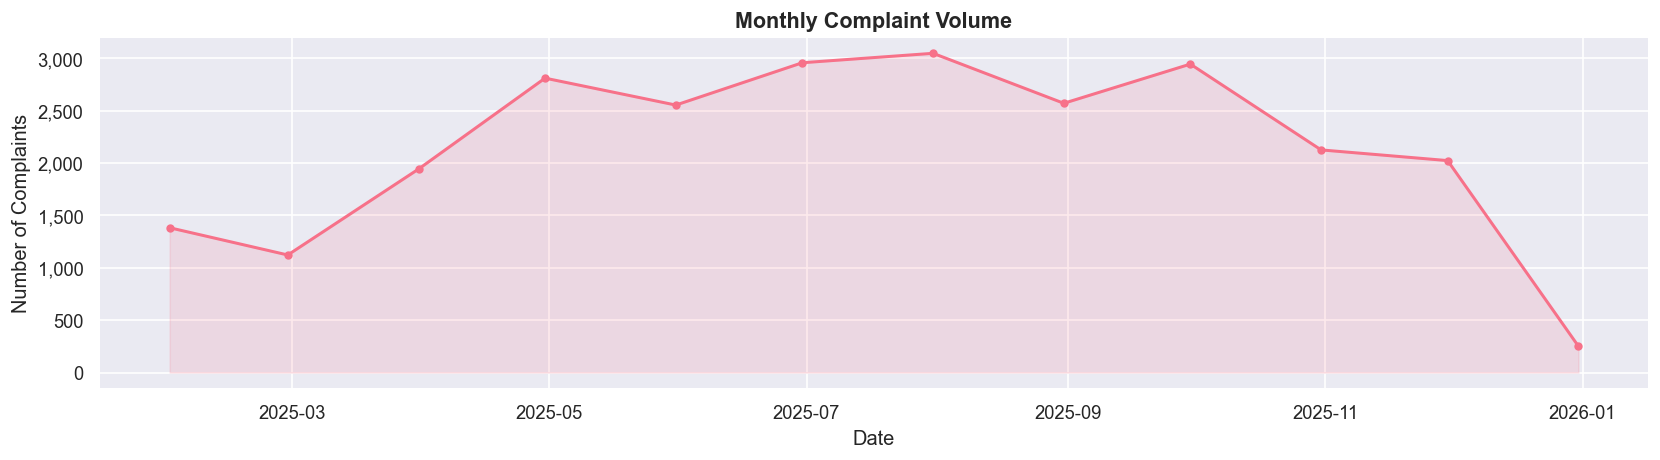

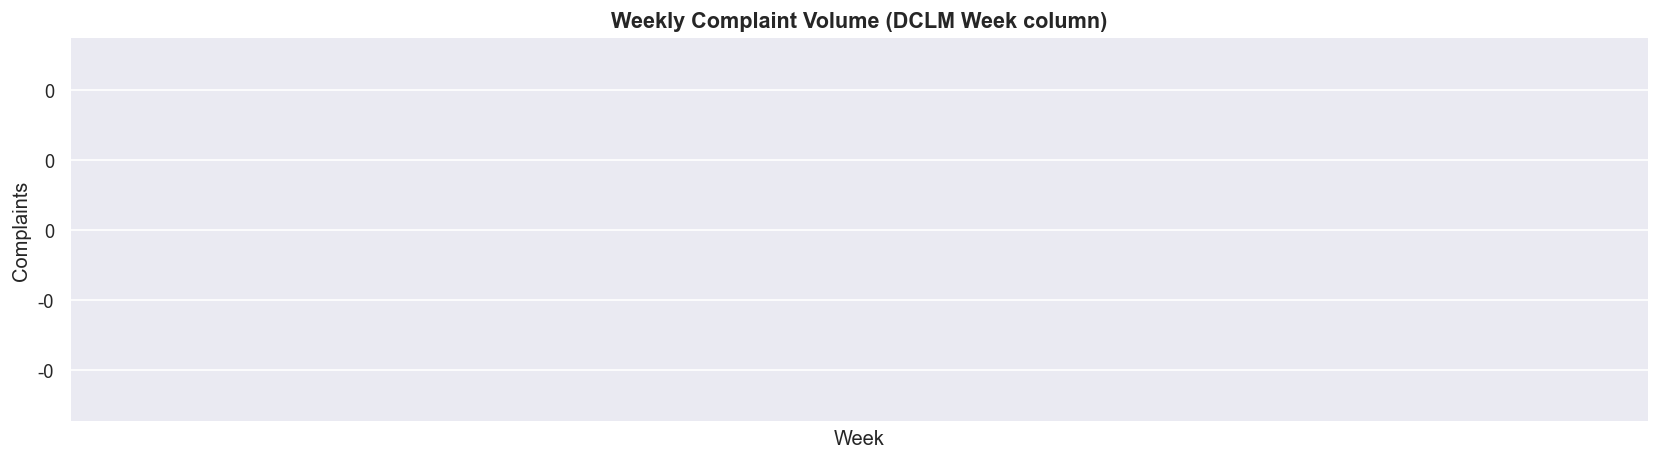

In [46]:
# FIX N4: use resample period alias compatible with both pandas <2.2 ("M")
# and >=2.2 ("ME").  We detect the installed version and choose accordingly.
_PD_MAJOR, _PD_MINOR = (int(x) for x in pd.__version__.split(".")[:2])
_MONTH_ALIAS = "ME" if (_PD_MAJOR, _PD_MINOR) >= (2, 2) else "M"

if C_TIMESTAMP in complaints.columns:
    ts_series = (
        complaints.set_index(C_TIMESTAMP)
        .resample(_MONTH_ALIAS)
        .size()
        .reset_index(name="count")
    )
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(ts_series[C_TIMESTAMP], ts_series["count"],
            linewidth=1.8, color=COLORS[0], marker="o", markersize=4)
    ax.fill_between(ts_series[C_TIMESTAMP], ts_series["count"],
                    alpha=0.15, color=COLORS[0])
    ax.set_title("Monthly Complaint Volume", fontsize=13, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of Complaints")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/eda_complaint_volume_monthly.png",
                dpi=150, bbox_inches="tight")
    plt.show()

# Weekly trend using the 'week' column from DCLM
if C_WEEK in complaints.columns and "year" in complaints.columns:
    weekly = (
        complaints.groupby(["year", C_WEEK])
        .size()
        .reset_index(name="count")
        .sort_values(["year", C_WEEK])
    )
    weekly["label"] = (
        weekly["year"].astype(str) + "-W"
        + weekly[C_WEEK].astype(str).str.zfill(2)
    )

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(range(len(weekly)), weekly["count"],
            linewidth=1.5, color=COLORS[2], marker="o", markersize=3)
    ax.fill_between(range(len(weekly)), weekly["count"],
                    alpha=0.15, color=COLORS[2])
    tick_step = max(1, len(weekly) // 12)
    ax.set_xticks(range(0, len(weekly), tick_step))
    ax.set_xticklabels(weekly["label"].iloc[::tick_step],
                       rotation=40, ha="right", fontsize=8)
    ax.set_title("Weekly Complaint Volume (DCLM Week column)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Week")
    ax.set_ylabel("Complaints")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/eda_complaint_weekly_trend.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## Cell 4 — Service type split

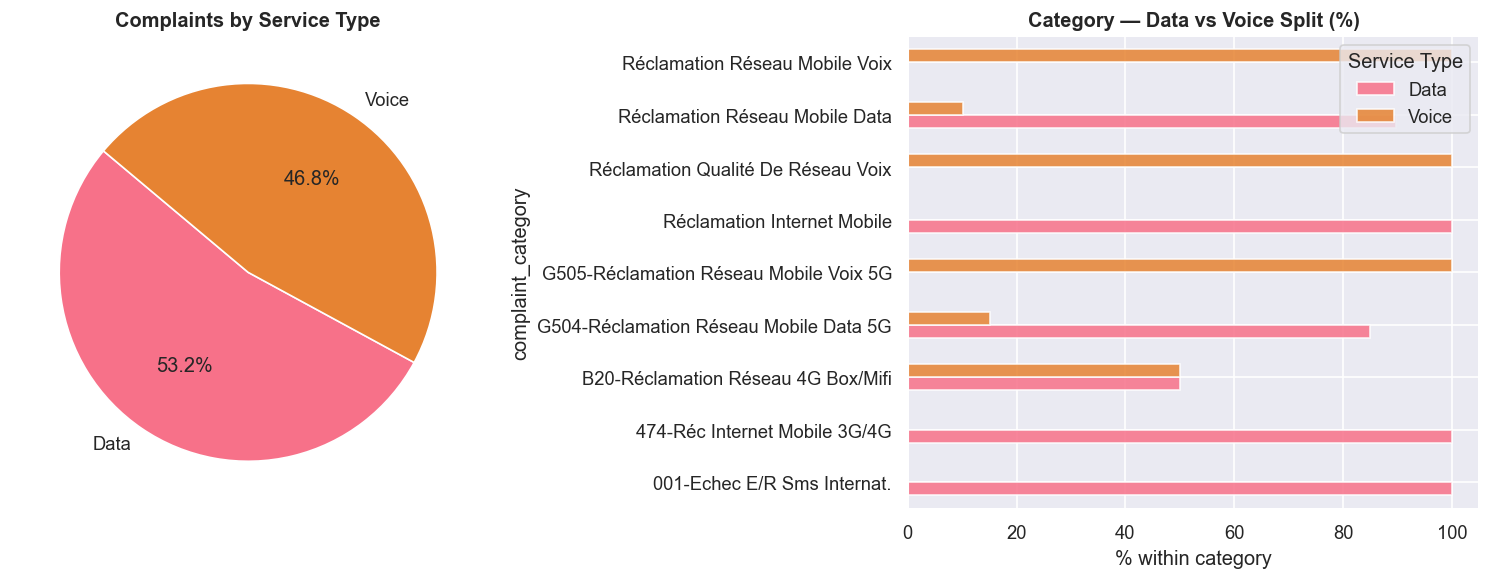


Service type breakdown:
  Data                   13,685  (53.2%)
  Voice                  12,042  (46.8%)


In [47]:
if C_TYPE in complaints.columns:
    counts = complaints[C_TYPE].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
                colors=COLORS[: len(counts)], startangle=140)
    axes[0].set_title("Complaints by Service Type",
                      fontsize=12, fontweight="bold")

    if C_CATEGORY in complaints.columns:
        ct = (
            pd.crosstab(complaints[C_CATEGORY], complaints[C_TYPE],
                        normalize="index")
            .mul(100)
            .round(1)
        )
        ct.plot(kind="barh", ax=axes[1],
                color=COLORS[: len(ct.columns)], alpha=0.85)
        axes[1].set_title("Category — Data vs Voice Split (%)",
                          fontsize=12, fontweight="bold")
        axes[1].set_xlabel("% within category")
        axes[1].legend(title="Service Type")

    plt.tight_layout()
    plt.savefig(f"{FIGURES}/eda_service_type.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nService type breakdown:")
    for svc, n in counts.items():
        print(f"  {svc:<20} {n:>8,}  ({n / len(complaints) * 100:.1f}%)")
else:
    print(f'Column "{C_TYPE}" not found in dataset')

## Cell 5 — Complaint categories

C:\Users\c50057188\AppData\Local\Temp\ipykernel_25680\3721211197.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=counts.index, x=counts.values, palette="husl", ax=ax,


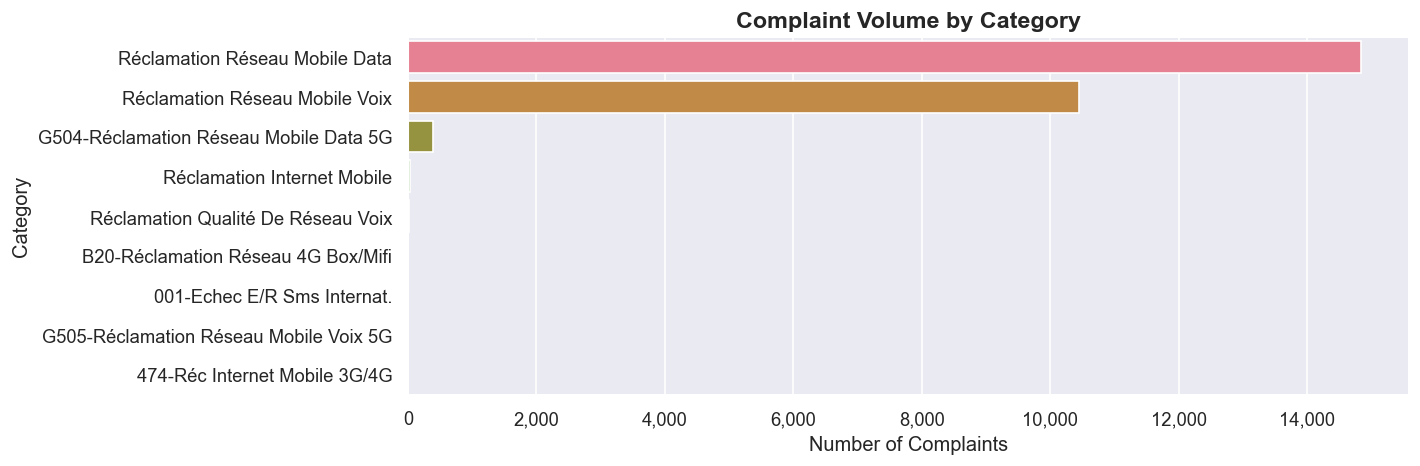


Category breakdown:
  Réclamation Réseau Mobile Data             14,841  (57.7%)
  Réclamation Réseau Mobile Voix             10,447  (40.6%)
  G504-Réclamation Réseau Mobile Data 5G        383  (1.5%)
  Réclamation Internet Mobile                    26  (0.1%)
  Réclamation Qualité De Réseau Voix             20  (0.1%)
  B20-Réclamation Réseau 4G Box/Mifi              4  (0.0%)
  001-Echec E/R Sms Internat.                     2  (0.0%)
  G505-Réclamation Réseau Mobile Voix 5G          2  (0.0%)
  474-Réc Internet Mobile 3G/4G                   2  (0.0%)


In [48]:
if C_CATEGORY in complaints.columns:
    counts = complaints[C_CATEGORY].value_counts()

    fig, ax = plt.subplots(figsize=(12, max(4, len(counts) * 0.45)))
    sns.barplot(y=counts.index, x=counts.values, palette="husl", ax=ax,
                orient="h")
    ax.set_title("Complaint Volume by Category",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Number of Complaints")
    ax.set_ylabel("Category")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/eda_complaint_category.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print("\nCategory breakdown:")
    for cat, n in counts.items():
        print(f"  {cat:<40} {n:>8,}  ({n / len(complaints) * 100:.1f}%)")
else:
    print(f'Column "{C_CATEGORY}" not found')

## Cell 6 — IT vs Network typology

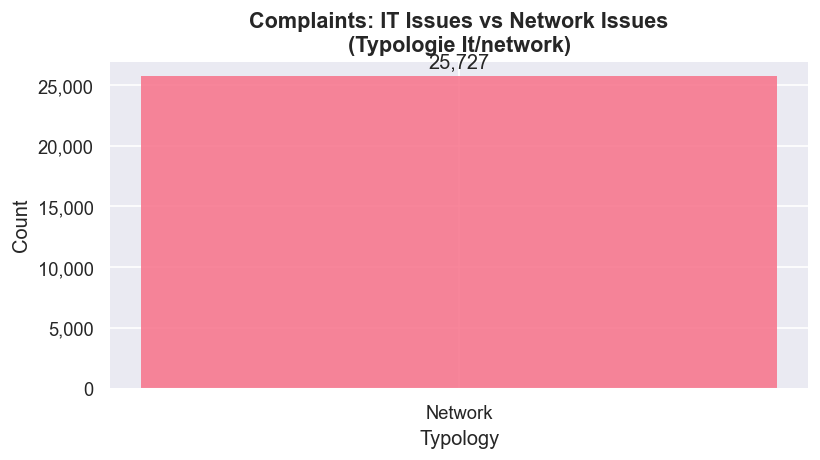

Typology breakdown:
complaint_typology
Network    25727


In [49]:
if C_TYPOLOGY in complaints.columns:
    counts = complaints[C_TYPOLOGY].value_counts()

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(counts.index, counts.values,
                  color=COLORS[: len(counts)], edgecolor="none", alpha=0.85)
    ax.bar_label(bars, labels=[f"{int(v):,}" for v in counts.values], padding=3)
    ax.set_title(
        "Complaints: IT Issues vs Network Issues\n(Typologie It/network)",
        fontsize=13, fontweight="bold",
    )
    ax.set_xlabel("Typology")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/eda_typology.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Typology breakdown:")
    print(counts.to_string())
else:
    print(f'Column "{C_TYPOLOGY}" not found in dataset')

## Cell 7 — Resolution status

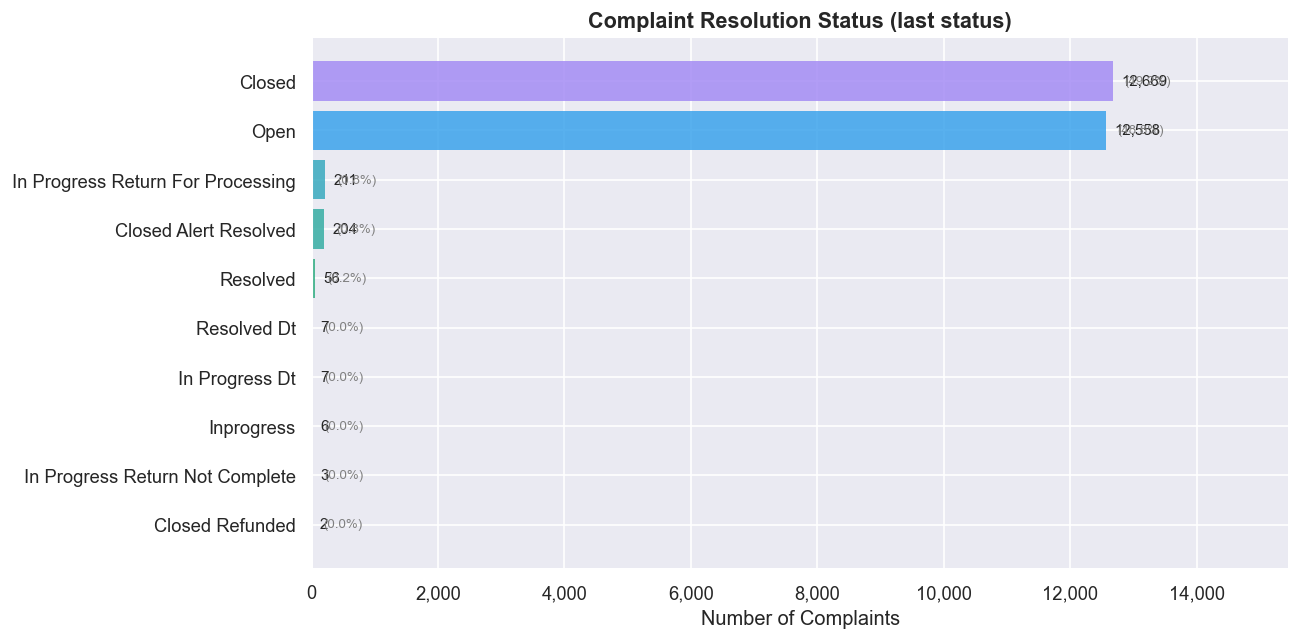

Resolution status breakdown:
  Closed                           12,669  (49.2%)
  Open                             12,558  (48.8%)
  In Progress Return For Processing      211  (0.8%)
  Closed Alert Resolved               204  (0.8%)
  Resolved                             56  (0.2%)
  In Progress Dt                        7  (0.0%)
  Resolved Dt                           7  (0.0%)
  Inprogress                            6  (0.0%)
  In Progress Return Not Complete        3  (0.0%)
  Closed Refunded                       2  (0.0%)
  Closed Dtfo                           1  (0.0%)
  In Progress Unfounded Return          1  (0.0%)
  Cancelled                             1  (0.0%)
  Reassign                              1  (0.0%)


In [50]:
if C_STATUS in complaints.columns:
    total_with_status = complaints[C_STATUS].notna().sum()
    counts = (
        complaints[C_STATUS].value_counts().sort_values(ascending=True).tail(10)
    )
    n = len(counts)
    fig, ax = plt.subplots(figsize=(11, max(4, n * 0.55)))
    bars = ax.barh(counts.index, counts.values,
                   color=[COLORS[i % len(COLORS)] for i in range(n)],
                   edgecolor="none", alpha=0.85)
    ax.bar_label(bars, labels=[f"{int(v):,}" for v in counts.values],
                 padding=5, fontsize=9)
    for bar, val in zip(bars, counts.values):
        pct = val / total_with_status * 100
        ax.text(
            bar.get_width() + counts.values.max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"({pct:.1f}%)", va="center", fontsize=8, color="grey",
        )
    ax.set_xlim(0, counts.values.max() * 1.22)
    ax.set_title("Complaint Resolution Status (last status)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Complaints")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/eda_resolution_status.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print("Resolution status breakdown:")
    for s, n_val in complaints[C_STATUS].value_counts().items():
        print(f"  {s:<30} {n_val:>8,}  ({n_val / total_with_status * 100:.1f}%)")
else:
    print(f'Column "{C_STATUS}" not found in dataset')

## Cell 8 — Provider group

C:\Users\c50057188\AppData\Local\Temp\ipykernel_25680\2064066189.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="husl", ax=ax)


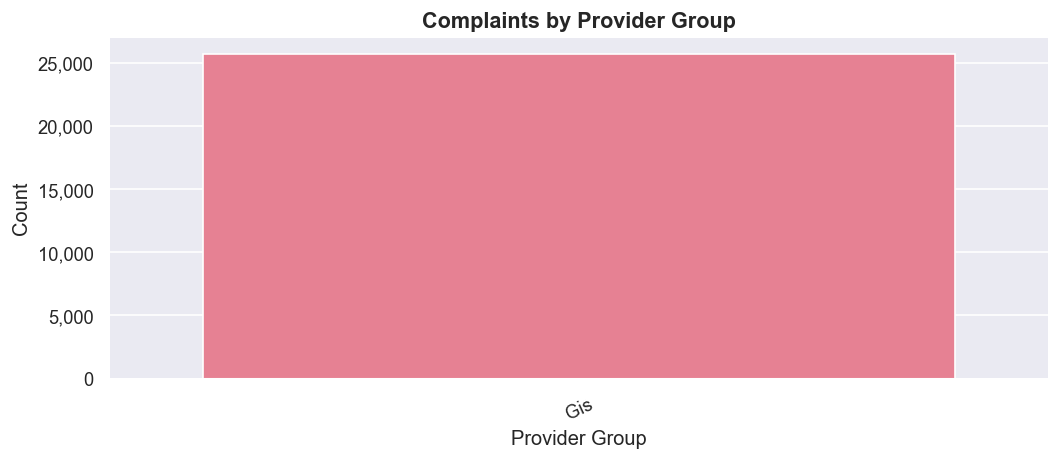

In [52]:
if C_PROVIDER in complaints.columns:
    counts = complaints[C_PROVIDER].value_counts()

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.barplot(x=counts.index, y=counts.values, palette="husl", ax=ax)
    ax.set_title("Complaints by Provider Group",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Provider Group")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=25)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/eda_provider_group.png",
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f'Column "{C_PROVIDER}" not found in dataset')

## Cell 9 — Geographic distribution

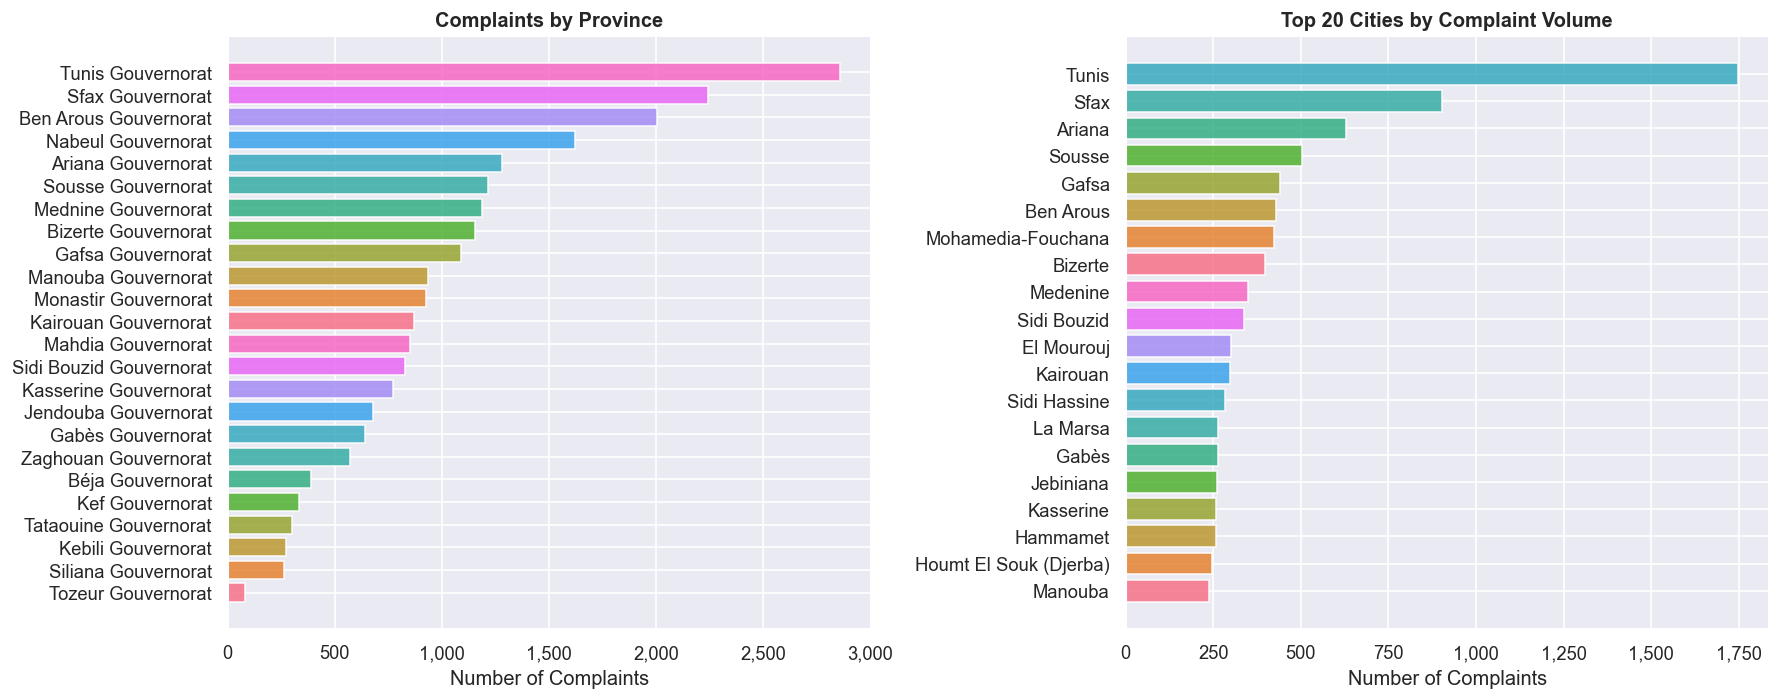

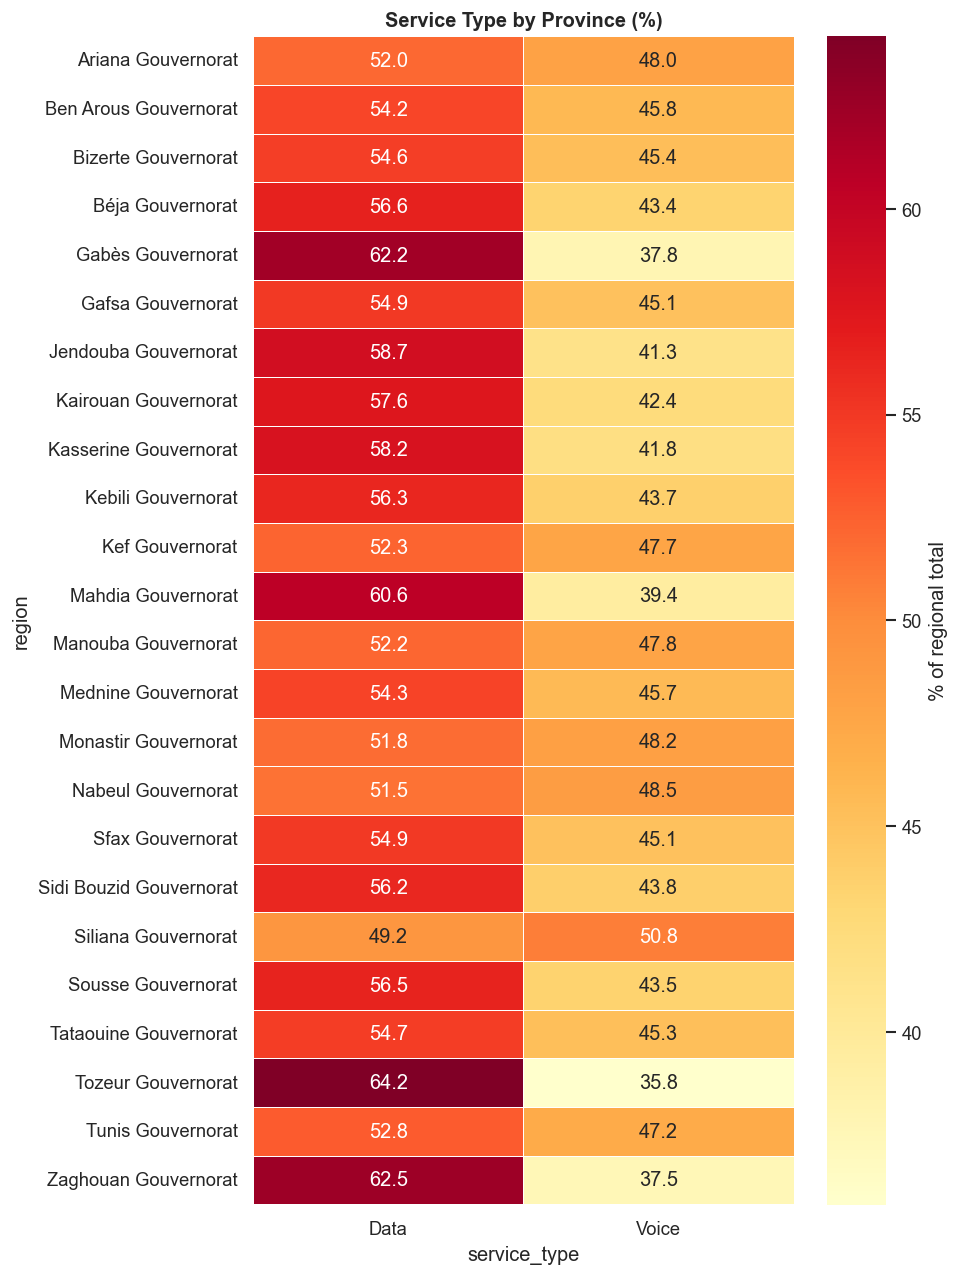

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

if C_PROVINCE in complaints.columns:
    prov = complaints[C_PROVINCE].value_counts().sort_values()
    axes[0].barh(
        prov.index, prov.values,
        color=[COLORS[i % len(COLORS)] for i in range(len(prov))], alpha=0.85,
    )
    axes[0].set_title("Complaints by Province", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Number of Complaints")
    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )
else:
    axes[0].text(0.5, 0.5, f'"{C_PROVINCE}" not found', ha="center", va="center")

if C_CITY in complaints.columns:
    city = complaints[C_CITY].value_counts().head(20).sort_values()
    axes[1].barh(
        city.index, city.values,
        color=[COLORS[i % len(COLORS)] for i in range(len(city))], alpha=0.85,
    )
    axes[1].set_title("Top 20 Cities by Complaint Volume",
                      fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Number of Complaints")
    axes[1].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )
else:
    axes[1].text(0.5, 0.5, f'"{C_CITY}" not found', ha="center", va="center")

plt.tight_layout()
plt.savefig(f"{FIGURES}/eda_geographic_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Province × Type heatmap
if C_PROVINCE in complaints.columns and C_TYPE in complaints.columns:
    pivot_pct = (
        pd.crosstab(complaints[C_PROVINCE], complaints[C_TYPE])
        .div(complaints[C_PROVINCE].value_counts(), axis=0)
        .mul(100)
        .round(1)
    )
    fig, ax = plt.subplots(figsize=(8, max(4, len(pivot_pct) * 0.45)))
    sns.heatmap(pivot_pct, annot=True, fmt=".1f", cmap="YlOrRd",
                linewidths=0.3, ax=ax, cbar_kws={"label": "% of regional total"})
    ax.set_title("Service Type by Province (%)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/eda_province_service_heatmap.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## Cell 10 — Customer segment

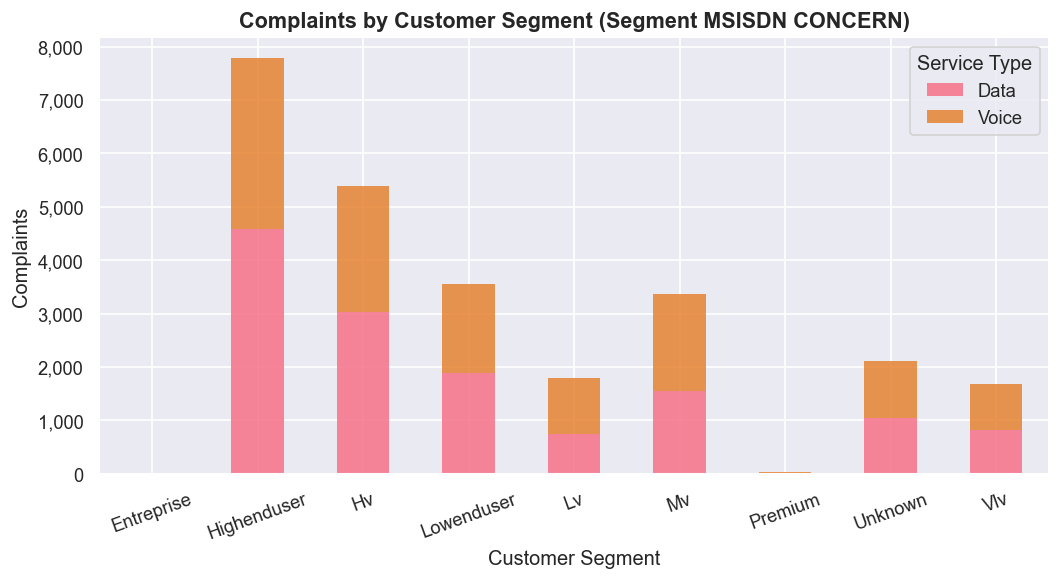

Customer segment breakdown:
customer_segment
Highenduser    7783
Hv             5388
Lowenduser     3563
Mv             3361
Unknown        2107
Lv             1802
Vlv            1686
Premium          30
Entreprise        7


In [54]:
if C_SEGMENT in complaints.columns:
    if C_TYPE in complaints.columns:
        pivot = (
            complaints.groupby([C_SEGMENT, C_TYPE])
            .size()
            .unstack(fill_value=0)
        )
    else:
        pivot = complaints.groupby(C_SEGMENT).size().to_frame("count")

    fig, ax = plt.subplots(figsize=(9, 5))
    pivot.plot(kind="bar", ax=ax, stacked=True,
               color=COLORS[: len(pivot.columns)], alpha=0.85, edgecolor="none")
    ax.set_title(
        "Complaints by Customer Segment (Segment MSISDN CONCERN)",
        fontsize=13, fontweight="bold",
    )
    ax.set_xlabel("Customer Segment")
    ax.set_ylabel("Complaints")
    ax.tick_params(axis="x", rotation=20)
    if C_TYPE in complaints.columns:
        ax.legend(title="Service Type")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/eda_customer_segment.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print("Customer segment breakdown:")
    print(complaints[C_SEGMENT].value_counts().to_string())
else:
    print(f'Column "{C_SEGMENT}" not found in dataset')

## Cell 11 — Hour × Day heatmap

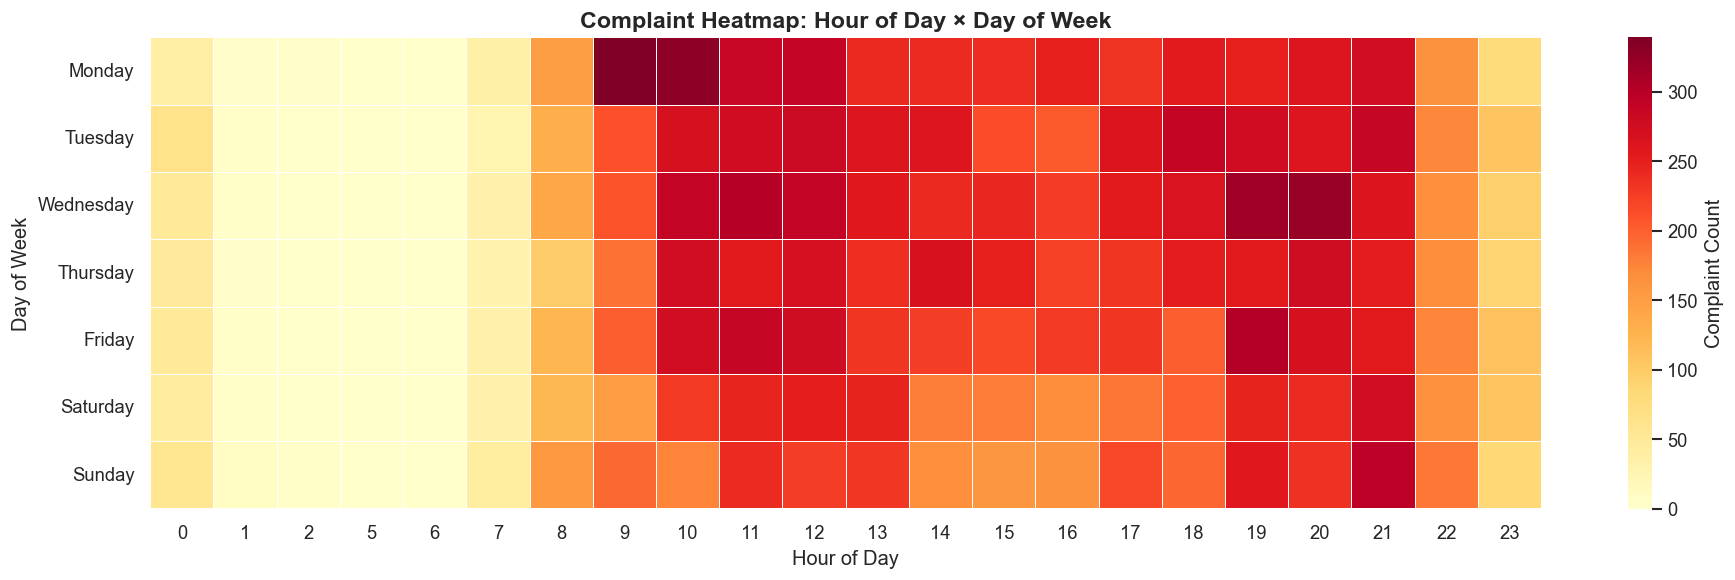

Peak hour : 19:00
Peak day  : Wednesday


In [55]:
if "hour" in complaints.columns and "day_of_week" in complaints.columns:
    _DAY_ORDER = [
        "Monday", "Tuesday", "Wednesday", "Thursday",
        "Friday", "Saturday", "Sunday",
    ]
    present_days = [d for d in _DAY_ORDER if d in complaints["day_of_week"].unique()]
    pivot = (
        complaints.groupby(["day_of_week", "hour"])
        .size()
        .unstack(fill_value=0)
        .reindex(present_days)
    )

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, ax=ax,
                cbar_kws={"label": "Complaint Count"})
    ax.set_title("Complaint Heatmap: Hour of Day × Day of Week",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Day of Week")
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/eda_heatmap_hour_day.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    peak_hour = complaints["hour"].value_counts().idxmax()
    peak_day  = complaints["day_of_week"].value_counts().idxmax()
    print(f"Peak hour : {peak_hour:02d}:00")
    print(f"Peak day  : {peak_day}")
else:
    print("Columns hour/day_of_week not found.")
    print("Ensure 'case open datetime' was parsed before running this cell.")

## Cell 12 — Sub-category top 15

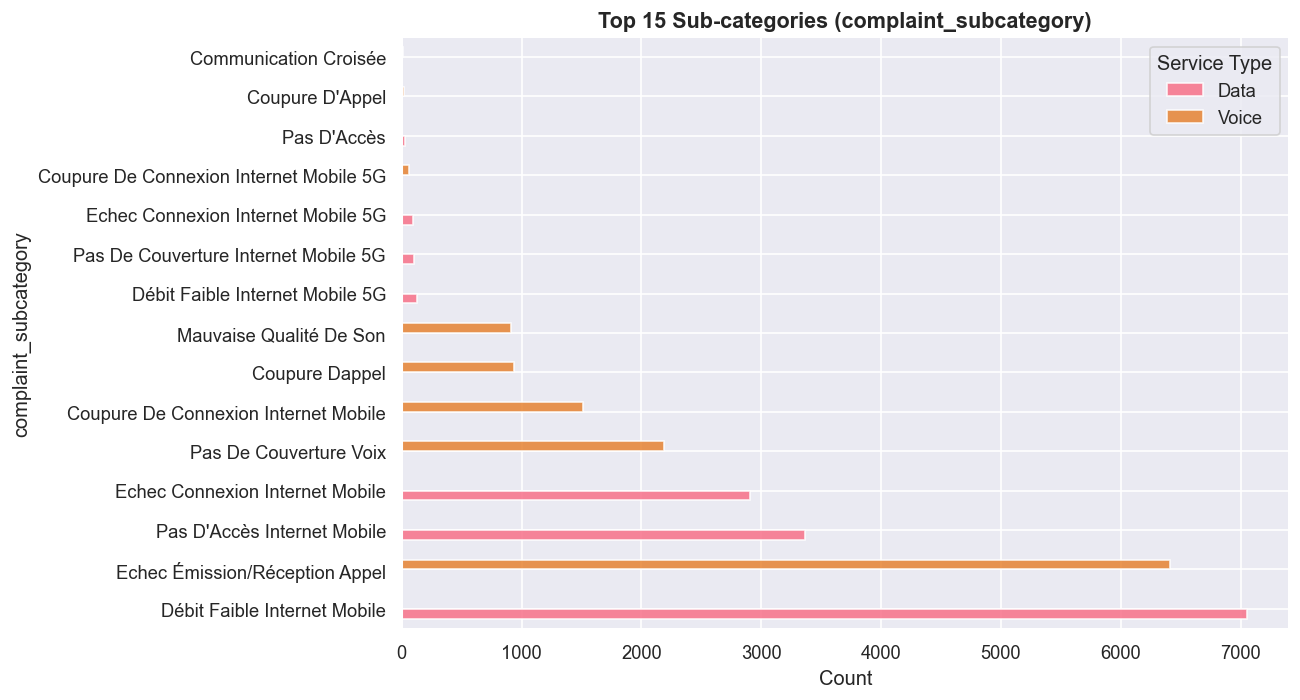

In [56]:
if C_SUBCAT in complaints.columns:
    top_vals = complaints[C_SUBCAT].value_counts().head(15).index

    if C_TYPE in complaints.columns:
        sub   = complaints[complaints[C_SUBCAT].isin(top_vals)]
        pivot = sub.groupby([C_SUBCAT, C_TYPE]).size().unstack(fill_value=0)
        fig, ax = plt.subplots(figsize=(11, 6))
        ordered = [v for v in top_vals if v in pivot.index]
        pivot.loc[ordered].plot(
            kind="barh", ax=ax,
            color=COLORS[: len(pivot.columns)], alpha=0.85,
        )
        ax.legend(title="Service Type")
    else:
        counts = complaints[C_SUBCAT].value_counts().head(15).sort_values()
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.barh(counts.index, counts.values, color=COLORS[0], alpha=0.85)

    ax.set_title("Top 15 Sub-categories (complaint_subcategory)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/eda_subcategory_top.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## Cell 13 — Data quality audit
FIX N11: missing_value_report inlined here so the notebook has no hidden
dependency on src.analysis.eda.  The function is 8 lines.

=== SHEET1 — MISSING VALUES ===


,column,missing_count,missing_pct
0,week,25727,100.00
1,city,2511,9.76
2,region,2375,9.23
3,customer_code,3,0.01



=== DUPLICATES ===
  Duplicate Case IDs  : 0
  Exact duplicate rows: 0

=== MSISDN ANALYSIS ===
  Unique MSISDNs      : 22,226
  Repeat complainants : 2,647
  Top 5 complainants:
    29378586.0  →  44 complaints
    21566820.0  →  10 complaints
    29641405.0  →  10 complaints
    26390481.0  →  8 complaints
    27984295.0  →  8 complaints


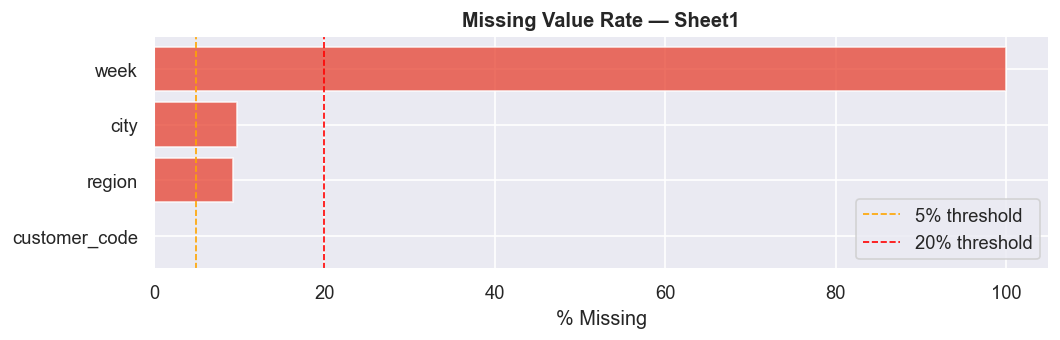

In [57]:
def missing_value_report(df: pd.DataFrame, name: str = "DataFrame") -> pd.DataFrame:
    """Return a sorted DataFrame of columns with missing values."""
    total = len(df)
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f"  {name}: no missing values ✓")
        return pd.DataFrame()
    report = pd.DataFrame({
        "column":       missing.index,
        "missing_count": missing.values,
        "missing_pct":  (missing.values / total * 100).round(2),
    }).sort_values("missing_pct", ascending=False).reset_index(drop=True)
    return report


print("=== SHEET1 — MISSING VALUES ===")
mv = missing_value_report(complaints, "Sheet1")
if not mv.empty:
    display(mv)  # type: ignore[name-defined]

print("\n=== DUPLICATES ===")
if C_CASEID in complaints.columns:
    print(f"  Duplicate Case IDs  : {complaints[C_CASEID].duplicated().sum()}")
print(f"  Exact duplicate rows: {complaints.duplicated().sum()}")

print("\n=== MSISDN ANALYSIS ===")
print(f"  Unique MSISDNs      : {complaints[C_MSISDN].nunique():,}")
print(f"  Repeat complainants : {(complaints[C_MSISDN].value_counts() > 1).sum():,}")
top5 = complaints[C_MSISDN].value_counts().head(5)
print("  Top 5 complainants:")
for msisdn, n_val in top5.items():
    print(f"    {msisdn}  →  {n_val} complaints")

# Missing value bar chart
nulls_pct = (complaints.isnull().sum() / len(complaints) * 100)
nulls_pct = nulls_pct[nulls_pct > 0].sort_values(ascending=True)

if not nulls_pct.empty:
    fig, ax = plt.subplots(figsize=(9, max(3, len(nulls_pct) * 0.5)))
    ax.barh(nulls_pct.index, nulls_pct.values, color="#e74c3c", alpha=0.8)
    ax.axvline(5,  color="orange", linestyle="--", lw=1, label="5% threshold")
    ax.axvline(20, color="red",    linestyle="--", lw=1, label="20% threshold")
    ax.set_title("Missing Value Rate — Sheet1", fontweight="bold")
    ax.set_xlabel("% Missing")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/eda_missing_values.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No missing values in main columns ✓")

## Cell 14 — Sweetviz automated EDA report
FIX N10: the D1 summary card referenced reports/sweetviz/ but no sweetviz
cell existed.  Added here.  Install with: pip install sweetviz

In [58]:
try:
    import sweetviz as sv

    _sv_cols = [c for c in complaints.columns
                if c not in (C_MSISDN, C_CUSTCODE, "customer_code")]
    sv_report = sv.analyze(complaints[_sv_cols], target_feat=C_TYPE)
    sv_report.show_html("reports/sweetviz/eda_sweetviz.html", open_browser=False)
    print("Sweetviz report saved → reports/sweetviz/eda_sweetviz.html")
except ImportError:
    print("sweetviz not installed — skipping automated report.")
    print("To enable: pip install sweetviz")

sweetviz not installed — skipping automated report.
To enable: pip install sweetviz


## Cell 15 — Generate synthetic KPI
Used as stand-in until Huawei delivers real DATA / VOICE exports.

In [59]:
from src.utils.synthetic_kpi_generator import generate_all_kpi, save_synthetic_kpi

print("Generating synthetic KPI calibrated on real complaints...")
kpi_synthetic = generate_all_kpi(
    complaints,
    sessions_per_complaint=2.5,
    corr_strength=0.35,
    seed=42,
)

print(f"\nShape      : {kpi_synthetic.shape}")
print(f"DATA rows  : {(kpi_synthetic['kpi_source'] == 'DATA').sum():,}")
print(f"VOICE rows : {(kpi_synthetic['kpi_source'] == 'VOICE').sum():,}")
print(f"Regions    : {sorted(kpi_synthetic['region'].unique())}")
print(
    f"Period     : {kpi_synthetic['timestamp'].min().date()} "
    f"→ {kpi_synthetic['timestamp'].max().date()}"
)
print("\nGenerated numeric KPIs:")
_kpi_num = [
    c for c in kpi_synthetic.select_dtypes("number").columns
    if c not in ("msisdn", "is_degraded_session")
]
for col in _kpi_num:
    print(f"  {col:<40} mean={kpi_synthetic[col].mean():.2f}")

os.makedirs("data/raw", exist_ok=True)
save_synthetic_kpi(kpi_synthetic, "data/raw/synthetic_kpi.parquet")

2026-05-06 11:49:47.887 | INFO     | src.utils.synthetic_kpi_generator:_generate:130 - Generating DATA sessions...


Generating synthetic KPI calibrated on real complaints...


2026-05-06 11:49:51.412 | INFO     | src.utils.synthetic_kpi_generator:_generate:267 -   DATA: 64,303 sessions | Good=36.9%  Fair=37.6%  Poor=25.5%
2026-05-06 11:49:51.469 | INFO     | src.utils.synthetic_kpi_generator:_generate:130 - Generating VOICE sessions...
2026-05-06 11:49:54.873 | INFO     | src.utils.synthetic_kpi_generator:_generate:267 -   VOICE: 64,341 sessions | Good=27.5%  Fair=64.6%  Poor=8.0%
2026-05-06 11:49:55.007 | SUCCESS  | src.utils.synthetic_kpi_generator:generate_all_kpi:108 - Synthetic KPI generated: 128,644 sessions  (DATA=64,303  VOICE=64,341  degraded=16.8%)



Shape      : (128644, 22)
DATA rows  : 64,303
VOICE rows : 64,341
Regions    : ['Ariana Gouvernorat', 'Ben Arous Gouvernorat', 'Bizerte Gouvernorat', 'Béja Gouvernorat', 'Gabès Gouvernorat', 'Gafsa Gouvernorat', 'Jendouba Gouvernorat', 'Kairouan Gouvernorat', 'Kasserine Gouvernorat', 'Kebili Gouvernorat', 'Kef Gouvernorat', 'Mahdia Gouvernorat', 'Manouba Gouvernorat', 'Mednine Gouvernorat', 'Monastir Gouvernorat', 'Nabeul Gouvernorat', 'Sfax Gouvernorat', 'Sidi Bouzid Gouvernorat', 'Siliana Gouvernorat', 'Sousse Gouvernorat', 'Tataouine Gouvernorat', 'Tozeur Gouvernorat', 'Tunis Gouvernorat', 'Zaghouan Gouvernorat']
Period     : 2025-01-01 → 2025-12-03

Generated numeric KPIs:
  dl_throughput_mbps                       mean=36.71
  ul_throughput_mbps                       mean=8.51
  latency_ms                               mean=68.86
  packet_loss_pct                          mean=2.82
  data_session_success_rate                mean=86.06
  data_qoe_score                           me

2026-05-06 11:49:55.571 | SUCCESS  | src.utils.synthetic_kpi_generator:save_synthetic_kpi:282 - Saved → data\raw\synthetic_kpi.parquet  (128,644 rows)


## Cell 16 — Synthetic KPI calibration check

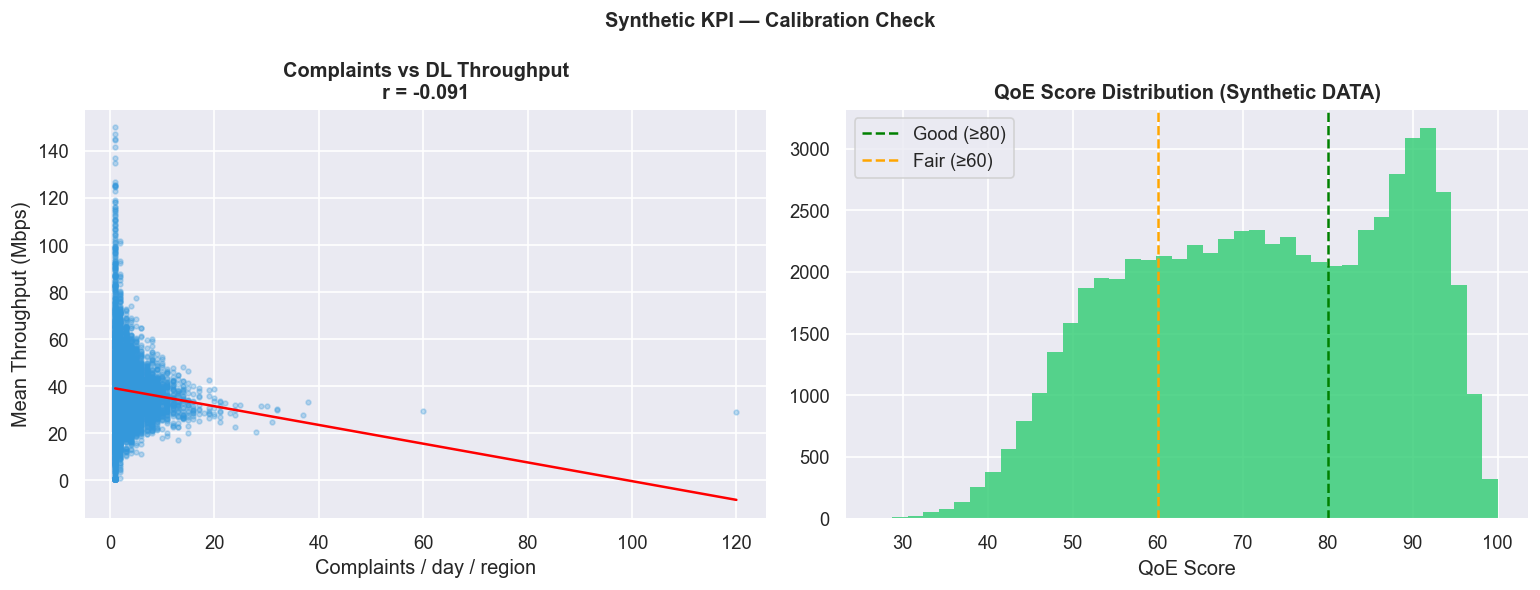

Complaint ↑ vs throughput ↓ correlation: r = -0.091


In [60]:
daily_c = (
    complaints.groupby(
        [C_PROVINCE, complaints[C_TIMESTAMP].dt.date.rename("date")]
    )
    .size()
    .reset_index(name="n_complaints")
)

data_only = kpi_synthetic[kpi_synthetic["kpi_source"] == "DATA"].copy()
daily_k = (
    data_only.groupby(
        ["region", data_only["timestamp"].dt.date.rename("date")]
    )["dl_throughput_mbps"]
    .mean()
    .reset_index(name="dl_mean")
)

joined = daily_c.merge(
    daily_k,
    left_on=[C_PROVINCE, "date"],
    right_on=["region", "date"],
    how="inner",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(joined["n_complaints"], joined["dl_mean"],
                alpha=0.3, s=8, color="#3498db")
if len(joined) > 1:
    z  = np.polyfit(joined["n_complaints"], joined["dl_mean"], 1)
    xs = np.linspace(joined["n_complaints"].min(),
                     joined["n_complaints"].max(), 100)
    axes[0].plot(xs, np.poly1d(z)(xs), color="red", linewidth=1.5)
r = joined["n_complaints"].corr(joined["dl_mean"])
axes[0].set_title(f"Complaints vs DL Throughput\nr = {r:.3f}",
                  fontweight="bold")
axes[0].set_xlabel("Complaints / day / region")
axes[0].set_ylabel("Mean Throughput (Mbps)")

axes[1].hist(data_only["qoe_score"].dropna(), bins=40,
             color="#2ecc71", alpha=0.8, edgecolor="none")
axes[1].axvline(80, color="green",  linestyle="--", lw=1.5, label="Good (≥80)")
axes[1].axvline(60, color="orange", linestyle="--", lw=1.5, label="Fair (≥60)")
axes[1].set_title("QoE Score Distribution (Synthetic DATA)", fontweight="bold")
axes[1].set_xlabel("QoE Score")
axes[1].legend()

plt.suptitle("Synthetic KPI — Calibration Check", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES}/eda_synthetic_kpi_calibration.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Complaint ↑ vs throughput ↓ correlation: r = {r:.3f}")

## Cell 17 — Expected real KPI schema (reference)

In [61]:
print("=== EXPECTED KPI COLUMNS FROM HUAWEI ===")
_EXPECTED = {
    "DATA sheet":  [
        "dl_throughput_mbps", "ul_throughput_mbps",
        "latency_ms", "packet_loss_pct",
        "data_session_success_rate", "data_qoe_score",
    ],
    "VOICE sheet": [
        "call_setup_success_rate", "call_drop_rate",
        "voice_quality_score_mos", "handover_success_rate",
        "voice_qoe_score",
    ],
}
for sheet_name, cols in _EXPECTED.items():
    print(f"\n  {sheet_name}:")
    for c in cols:
        print(f"    - {c}")

=== EXPECTED KPI COLUMNS FROM HUAWEI ===

  DATA sheet:
    - dl_throughput_mbps
    - ul_throughput_mbps
    - latency_ms
    - packet_loss_pct
    - data_session_success_rate
    - data_qoe_score

  VOICE sheet:
    - call_setup_success_rate
    - call_drop_rate
    - voice_quality_score_mos
    - handover_success_rate
    - voice_qoe_score


## Cell 18 — Deliverable D1: Professional EDA Summary Figure

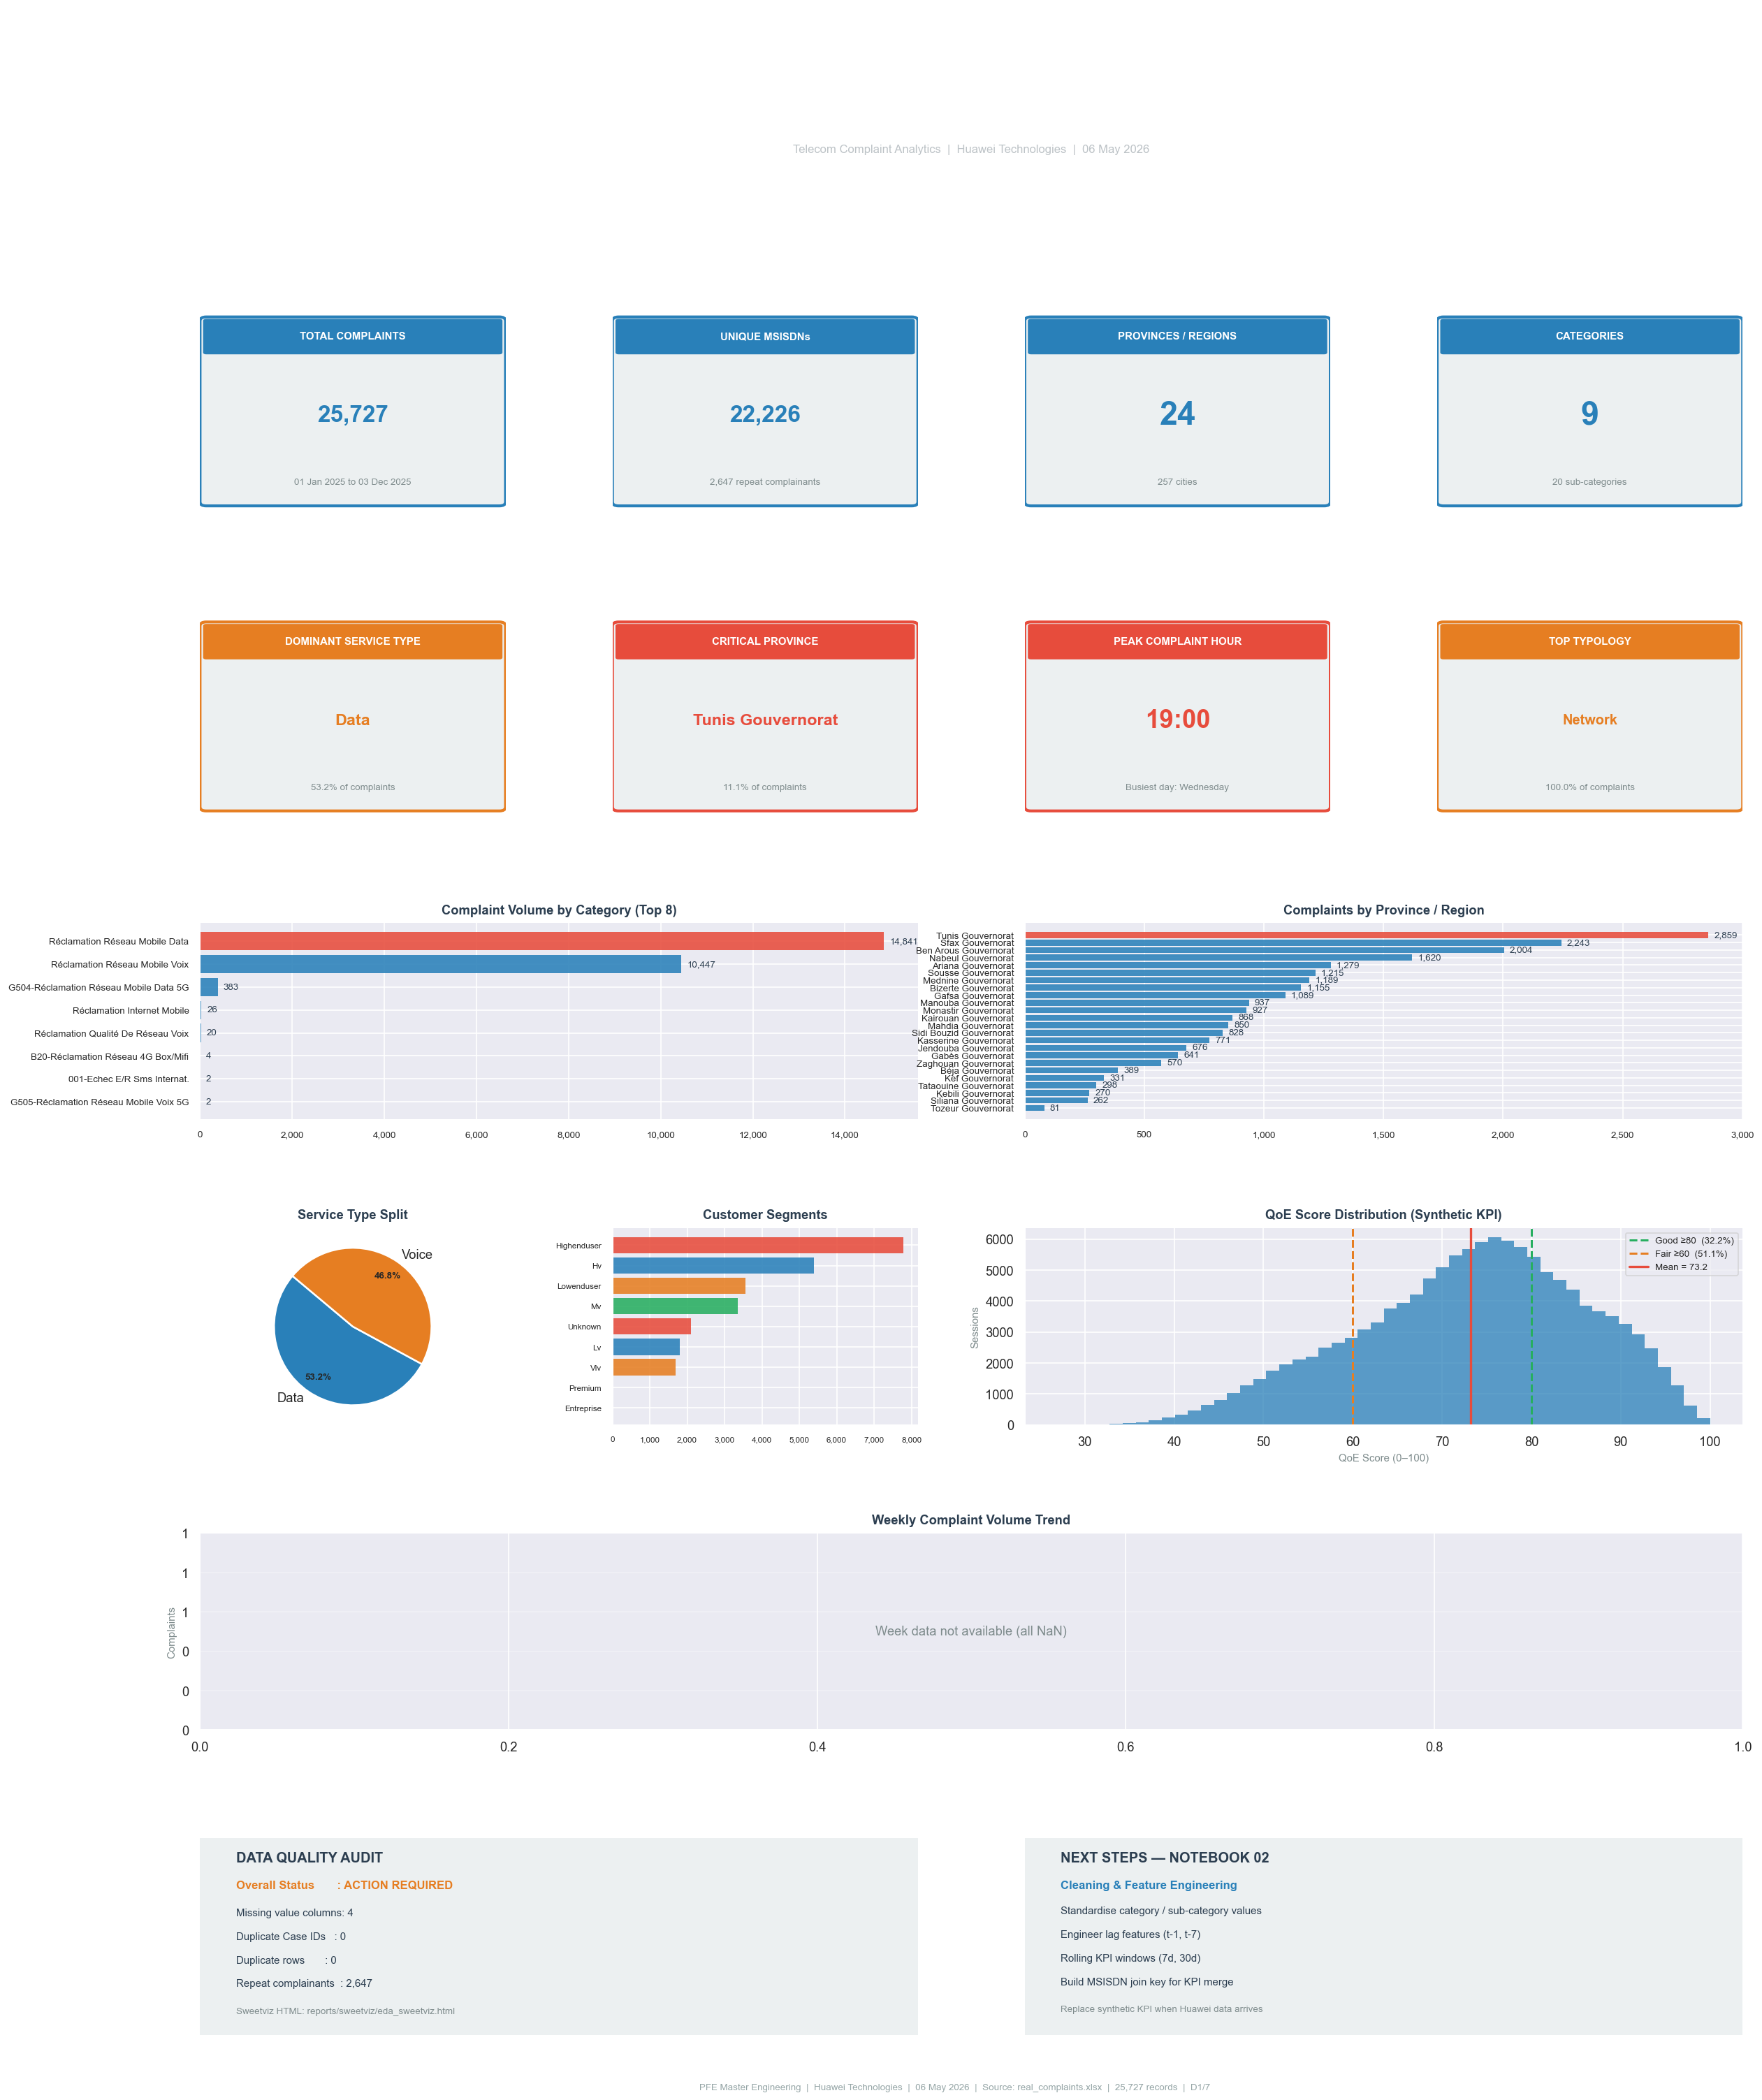

Report saved: reports/figures/D1_EDA_Summary_Report.png


In [62]:
# %% [markdown]
# ## Cell 18 — Deliverable D1: Professional EDA Summary Figure
 
# %%
# FIX N2: removed duplicate datetime import (had both `import datetime` AND
#          `from datetime import datetime` in the original cell).
# FIX N3: kpi_synthetic is now guaranteed to exist (generated in Cell 15).
# FIX N9: removed the unused `figures_saved` variable.
 
import datetime  # standard library — for datetime.datetime.now()
from matplotlib import gridspec
import matplotlib.patches as mpatches
 
C1 = "#2C3E50"; C2 = "#2980B9"; C3 = "#27AE60"
C4 = "#E67E22"; C5 = "#E74C3C"; CG = "#ECF0F1"
 
# ── Safe metric collection ────────────────────────────────────────────────────
total         = len(complaints)
n_msisdn      = complaints[C_MSISDN].nunique()    if C_MSISDN    in complaints.columns else 0
repeat_msisdn = int((complaints[C_MSISDN].value_counts() > 1).sum()) if C_MSISDN in complaints.columns else 0
n_provinces   = complaints[C_PROVINCE].nunique()  if C_PROVINCE  in complaints.columns else 0
n_cities      = complaints[C_CITY].nunique()      if C_CITY      in complaints.columns else 0
n_categories  = complaints[C_CATEGORY].nunique()  if C_CATEGORY  in complaints.columns else 0
n_subcats     = complaints[C_SUBCAT].nunique()     if C_SUBCAT    in complaints.columns else 0
miss_cols     = int((complaints.isnull().sum() > 0).sum())
dup_ids       = int(complaints[C_CASEID].duplicated().sum()) if C_CASEID in complaints.columns else 0
 
def _top_value(col: str) -> tuple[str, float]:
    """Return (top_value_label, pct_of_total) for a column, safely."""
    if col not in complaints.columns:
        return "N/A", 0.0
    vc = complaints[col].value_counts()
    if vc.empty:
        return "N/A", 0.0
    return str(vc.index[0]), vc.iloc[0] / total * 100
 
top_type,     top_type_pct  = _top_value(C_TYPE)
top_province, top_prov_pct  = _top_value(C_PROVINCE)
top_cat,      top_cat_pct   = _top_value(C_CATEGORY)
top_segment,  top_seg_pct   = _top_value(C_SEGMENT)
top_typology, top_typo_pct  = _top_value(C_TYPOLOGY)
 
# Peak hour / day
if "hour" in complaints.columns:
    peak_hour = int(complaints["hour"].value_counts().idxmax())
    peak_day  = (
        complaints["day_of_week"].value_counts().index[0]
        if "day_of_week" in complaints.columns else "N/A"
    )
else:
    peak_hour, peak_day = 0, "N/A"
 
# Period
if C_TIMESTAMP in complaints.columns:
    ts_col      = pd.to_datetime(complaints[C_TIMESTAMP], errors="coerce")
    period_from = ts_col.min().strftime("%d %b %Y")
    period_to   = ts_col.max().strftime("%d %b %Y")
else:
    period_from = period_to = "N/A"
 
# KPI metrics
good_pct = (kpi_synthetic["qoe_score"] >= 80).mean() * 100
fair_pct = ((kpi_synthetic["qoe_score"] >= 60) & (kpi_synthetic["qoe_score"] < 80)).mean() * 100
mean_qoe = kpi_synthetic["qoe_score"].mean()
 
# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 26), facecolor="white")
gs  = gridspec.GridSpec(
    7, 4, figure=fig,
    hspace=0.55, wspace=0.35,
    top=0.96, bottom=0.03, left=0.05, right=0.97,
)
 
 
def kpi_card(ax, value: str, label: str, sublabel: str = "",
             color: str = C2, vfs: int = 28) -> None:
    """Draw a styled KPI card on the given Axes."""
    ax.set_facecolor(CG)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.02, 0.04), 0.96, 0.92,
        boxstyle="round,pad=0.02", facecolor=CG, edgecolor=color, linewidth=2.5,
    ))
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.02, 0.80), 0.96, 0.16,
        boxstyle="round,pad=0.01", facecolor=color, edgecolor="none",
    ))
    ax.text(0.5, 0.88, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white",
            transform=ax.transAxes)
    ax.text(0.5, 0.48, str(value), ha="center", va="center",
            fontsize=vfs, fontweight="bold", color=color,
            transform=ax.transAxes)
    if sublabel:
        ax.text(0.5, 0.14, sublabel, ha="center", va="center",
                fontsize=8, color="#7F8C8D", transform=ax.transAxes)
 
 
# Header
ax_hdr = fig.add_subplot(gs[0, :])
ax_hdr.set_facecolor(C1)
ax_hdr.set_xlim(0, 1); ax_hdr.set_ylim(0, 1); ax_hdr.axis("off")
ax_hdr.text(0.5, 0.72,
            "DELIVERABLE D1 — EXPLORATORY DATA ANALYSIS REPORT",
            ha="center", va="center", fontsize=16, fontweight="bold",
            color="white", transform=ax_hdr.transAxes)
ax_hdr.text(
    0.5, 0.28,
    f"Telecom Complaint Analytics  |  Huawei Technologies  |  "
    f"{datetime.datetime.now().strftime('%d %B %Y')}",
    ha="center", va="center", fontsize=10,
    color="#BDC3C7", transform=ax_hdr.transAxes,
)
 
# Row 1 — dataset cards
kpi_card(fig.add_subplot(gs[1, 0]), f"{total:,}", "TOTAL COMPLAINTS",
         f"{period_from} to {period_to}", C2, 20)
kpi_card(fig.add_subplot(gs[1, 1]),
         f"{n_msisdn:,}" if n_msisdn else "N/A", "UNIQUE MSISDNs",
         f"{repeat_msisdn:,} repeat complainants", C2, 20)
kpi_card(fig.add_subplot(gs[1, 2]), str(n_provinces), "PROVINCES / REGIONS",
         f"{n_cities} cities" if n_cities else "", C2, 28)
kpi_card(fig.add_subplot(gs[1, 3]), str(n_categories), "CATEGORIES",
         f"{n_subcats} sub-categories" if n_subcats else "", C2, 28)
 
# Row 2 — insight cards
kpi_card(fig.add_subplot(gs[2, 0]), top_type,
         "DOMINANT SERVICE TYPE", f"{top_type_pct:.1f}% of complaints", C4, 14)
kpi_card(fig.add_subplot(gs[2, 1]), top_province,
         "CRITICAL PROVINCE", f"{top_prov_pct:.1f}% of complaints", C5, 14)
kpi_card(fig.add_subplot(gs[2, 2]), f"{peak_hour:02d}:00",
         "PEAK COMPLAINT HOUR", f"Busiest day: {peak_day}", C5, 22)
kpi_card(fig.add_subplot(gs[2, 3]), top_typology,
         "TOP TYPOLOGY", f"{top_typo_pct:.1f}% of complaints", C4, 12)
 
# Row 3 — category & province bars
ax_cat = fig.add_subplot(gs[3, :2])
if C_CATEGORY in complaints.columns:
    cat_counts = complaints[C_CATEGORY].value_counts().head(8)
    col_bars   = [C5 if i == 0 else C2 for i in range(len(cat_counts))]
    bars = ax_cat.barh(cat_counts.index[::-1], cat_counts.values[::-1],
                       color=col_bars[::-1], alpha=0.88, edgecolor="none")
    ax_cat.bar_label(
        bars, labels=[f"{int(v):,}" for v in cat_counts.values[::-1]],
        padding=5, fontsize=8, color=C1,
    )
    ax_cat.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )
ax_cat.set_title("Complaint Volume by Category (Top 8)",
                 fontsize=11, fontweight="bold", color=C1, pad=8)
ax_cat.spines[["top", "right"]].set_visible(False)
ax_cat.tick_params(labelsize=8)
 
ax_reg = fig.add_subplot(gs[3, 2:])
if C_PROVINCE in complaints.columns:
    reg_counts = complaints[C_PROVINCE].value_counts()
    col_reg    = [C5 if i == 0 else C2 for i in range(len(reg_counts))]
    bars2 = ax_reg.barh(reg_counts.index[::-1], reg_counts.values[::-1],
                        color=col_reg[::-1], alpha=0.88, edgecolor="none")
    ax_reg.bar_label(
        bars2, labels=[f"{int(v):,}" for v in reg_counts.values[::-1]],
        padding=5, fontsize=8, color=C1,
    )
    ax_reg.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )
ax_reg.set_title("Complaints by Province / Region",
                 fontsize=11, fontweight="bold", color=C1, pad=8)
ax_reg.spines[["top", "right"]].set_visible(False)
ax_reg.tick_params(labelsize=8)
 
# Row 4 — service type pie / segment bar / QoE histogram
ax_pie = fig.add_subplot(gs[4, 0])
if C_TYPE in complaints.columns:
    svc = complaints[C_TYPE].value_counts()
    wedges, texts, autotexts = ax_pie.pie(
        svc.values, labels=svc.index, autopct="%1.1f%%",
        colors=[C2, C4, C5, C3][: len(svc)], startangle=140,
        pctdistance=0.78, wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    )
    for t in autotexts:
        t.set_fontsize(8); t.set_fontweight("bold")
ax_pie.set_title("Service Type Split", fontsize=11, fontweight="bold",
                 color=C1, pad=8)
 
ax_seg = fig.add_subplot(gs[4, 1])
if C_SEGMENT in complaints.columns:
    seg = complaints[C_SEGMENT].value_counts()
    ax_seg.barh(seg.index[::-1], seg.values[::-1],
                color=[C2, C4, C3, C5][: len(seg)][::-1],
                alpha=0.88, edgecolor="none")
    ax_seg.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:,.0f}")
    )
ax_seg.set_title("Customer Segments", fontsize=11, fontweight="bold",
                 color=C1, pad=8)
ax_seg.spines[["top", "right"]].set_visible(False)
ax_seg.tick_params(labelsize=7)
 
ax_qoe = fig.add_subplot(gs[4, 2:])
qoe_vals = kpi_synthetic["qoe_score"].dropna()
ax_qoe.hist(qoe_vals, bins=50, color=C2, alpha=0.75, edgecolor="none")
ax_qoe.axvline(80, color=C3, linestyle="--", lw=1.8,
               label=f"Good ≥80  ({good_pct:.1f}%)")
ax_qoe.axvline(60, color=C4, linestyle="--", lw=1.8,
               label=f"Fair ≥60  ({fair_pct:.1f}%)")
ax_qoe.axvline(mean_qoe, color=C5, linestyle="-", lw=2,
               label=f"Mean = {mean_qoe:.1f}")
ax_qoe.set_title("QoE Score Distribution (Synthetic KPI)",
                 fontsize=11, fontweight="bold", color=C1, pad=8)
ax_qoe.set_xlabel("QoE Score (0–100)", fontsize=9, color="#7F8C8D")
ax_qoe.set_ylabel("Sessions", fontsize=9, color="#7F8C8D")
ax_qoe.legend(fontsize=8, framealpha=0.7)
ax_qoe.spines[["top", "right"]].set_visible(False)
 
# Row 5 — weekly trend
ax_ts = fig.add_subplot(gs[5, :])
 
# Build weekly aggregation (drop NaN week values before groupby)
_week_col_ok = (
    C_WEEK in complaints.columns
    and complaints[C_WEEK].notna().any()
)
if _week_col_ok:
    _base = complaints.dropna(subset=[C_WEEK])
    if "year" in _base.columns:
        weekly = (
            _base.groupby(["year", C_WEEK])
            .size().reset_index(name="count")
            .sort_values(["year", C_WEEK])
        )
        weekly["label"] = (
            weekly["year"].astype(str) + "-W"
            + weekly[C_WEEK].astype(str).str.zfill(2)
        )
    else:
        weekly = (
            _base.groupby(C_WEEK)
            .size().reset_index(name="count")
            .sort_values(C_WEEK)
        )
        weekly["label"] = "W" + weekly[C_WEEK].astype(str).str.zfill(2)
else:
    weekly = pd.DataFrame()   # will fall through to the placeholder text
 
if not weekly.empty:
    ax_ts.plot(range(len(weekly)), weekly["count"],
               color=C2, linewidth=1.8, zorder=3)
    ax_ts.fill_between(range(len(weekly)), weekly["count"],
                       alpha=0.15, color=C2)
 
    # Peak annotation — safe because we confirmed weekly is non-empty
    peak_idx = weekly["count"].idxmax()
    peak_pos = weekly.index.get_loc(peak_idx)
    ax_ts.annotate(
        f"Peak: {int(weekly.loc[peak_idx, 'count']):,}",
        xy=(peak_pos, weekly.loc[peak_idx, "count"]),
        xytext=(10, 12), textcoords="offset points",
        fontsize=8, color=C5,
        arrowprops=dict(arrowstyle="->", color=C5, lw=1.2),
    )
    tick_step = max(1, len(weekly) // 14)
    ax_ts.set_xticks(range(0, len(weekly), tick_step))
    ax_ts.set_xticklabels(weekly["label"].iloc[::tick_step],
                          rotation=35, ha="right", fontsize=7)
else:
    ax_ts.text(0.5, 0.5, "Week data not available (all NaN)",
               ha="center", va="center", fontsize=11, color="#7F8C8D",
               transform=ax_ts.transAxes)
 
ax_ts.set_title("Weekly Complaint Volume Trend",
                fontsize=11, fontweight="bold", color=C1, pad=8)
ax_ts.set_ylabel("Complaints", fontsize=9, color="#7F8C8D")
ax_ts.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax_ts.spines[["top", "right"]].set_visible(False)
ax_ts.grid(axis="y", alpha=0.3)
 
# Row 6 — quality audit + next steps
dq_color  = C3 if miss_cols == 0 and dup_ids == 0 else C4
dq_status = "PASS  ✓" if miss_cols == 0 and dup_ids == 0 else "ACTION REQUIRED"
sweetviz_path = "reports/sweetviz/eda_sweetviz.html"
 
_PANELS = [
    ("DATA QUALITY AUDIT", dq_color, [
        (f"Overall Status       : {dq_status}", 10, dq_color, "bold",   0.76),
        (f"Missing value columns: {miss_cols}",  9, C1,       "normal", 0.62),
        (f"Duplicate Case IDs   : {dup_ids}",    9, C1,       "normal", 0.50),
        (f"Duplicate rows       : {complaints.duplicated().sum()}", 9, C1, "normal", 0.38),
        (f"Repeat complainants  : {repeat_msisdn:,}", 9, C1,  "normal", 0.26),
        (f"Sweetviz HTML: {sweetviz_path}", 8, "#7F8C8D", "normal", 0.12),
    ]),
    ("NEXT STEPS — NOTEBOOK 02", C2, [
        ("Cleaning & Feature Engineering",               10, C2,      "bold",   0.76),
        ("Standardise category / sub-category values",   9,  C1,      "normal", 0.63),
        ("Engineer lag features (t-1, t-7)",             9,  C1,      "normal", 0.51),
        ("Rolling KPI windows (7d, 30d)",                9,  C1,      "normal", 0.39),
        ("Build MSISDN join key for KPI merge",          9,  C1,      "normal", 0.27),
        ("Replace synthetic KPI when Huawei data arrives", 8, "#7F8C8D", "normal", 0.13),
    ]),
]
 
for col_idx, (title, color_border, lines) in enumerate(_PANELS):
    ax_p = fig.add_subplot(gs[6, col_idx * 2: col_idx * 2 + 2])
    ax_p.set_facecolor(CG); ax_p.axis("off")
    ax_p.add_patch(mpatches.FancyBboxPatch(
        (0.01, 0.01), 0.98, 0.98,
        boxstyle="round,pad=0.02", facecolor=CG,
        edgecolor=color_border, linewidth=1.5,
    ))
    ax_p.text(0.05, 0.90, title, fontsize=12, color=C1, fontweight="bold",
              transform=ax_p.transAxes, va="center")
    for text, fs, col, fw, y in lines:
        ax_p.text(0.05, y, text, fontsize=fs, color=col, fontweight=fw,
                  transform=ax_p.transAxes, va="center")
 
# Footer
fig.text(
    0.5, 0.005,
    f"PFE Master Engineering  |  Huawei Technologies  |  "
    f"{datetime.datetime.now().strftime('%d %B %Y')}  |  "
    f"Source: real_complaints.xlsx  |  {total:,} records  |  D1/7",
    ha="center", fontsize=8, color="#95A5A6",
)
 
out_path = f"{FIGURES}/D1_EDA_Summary_Report.png"
fig.savefig(out_path, dpi=180, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print(f"Report saved: {out_path}")